# 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [4]:
from torchvision.datasets import FashionMNIST

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = FashionMNIST(
    root="/kaggle/working",
    train=True,
    download=True,
    transform=transform
)

test_dataset = FashionMNIST(
    root="/kaggle/working",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print("Training :", len(train_dataset))
print("Testing :", len(test_dataset))

100%|██████████| 26.4M/26.4M [00:01<00:00, 22.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 338kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.24MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.2MB/s]

Training : 60000
Testing : 10000


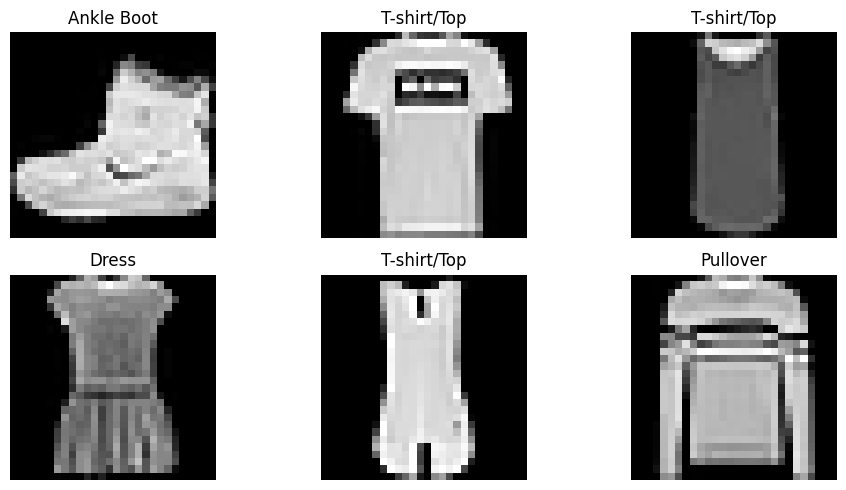

In [5]:
# Nama kelas Fashion-MNIST
classes = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

# Menampilkan 6 gambar pertama
plt.figure(figsize=(10,5))

for i in range(6):
    image, label = train_dataset[i]

    plt.subplot(2,3,i+1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(classes[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
# Autoencoder

latent_dim = 32   
class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        out = out.view(-1, 1, 28, 28)
        return out

model = Autoencoder(latent_dim)

print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


In [20]:
# Training Autoencoder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = Autoencoder(latent_dim).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20
loss_history = []

for epoch in range(epochs):

    running_loss = 0

    for images, _ in train_loader:

        images = images.to(device)

        outputs = model(images)

        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.6f}")

Device: cuda
Epoch [1/20] Loss: 0.037121
Epoch [2/20] Loss: 0.020306
Epoch [3/20] Loss: 0.017651
Epoch [4/20] Loss: 0.016203
Epoch [5/20] Loss: 0.015051
Epoch [6/20] Loss: 0.014046
Epoch [7/20] Loss: 0.013278
Epoch [8/20] Loss: 0.012657
Epoch [9/20] Loss: 0.012171
Epoch [10/20] Loss: 0.011784
Epoch [11/20] Loss: 0.011432
Epoch [12/20] Loss: 0.011130
Epoch [13/20] Loss: 0.010876
Epoch [14/20] Loss: 0.010632
Epoch [15/20] Loss: 0.010448
Epoch [16/20] Loss: 0.010271
Epoch [17/20] Loss: 0.010125
Epoch [18/20] Loss: 0.009976
Epoch [19/20] Loss: 0.009825
Epoch [20/20] Loss: 0.009709


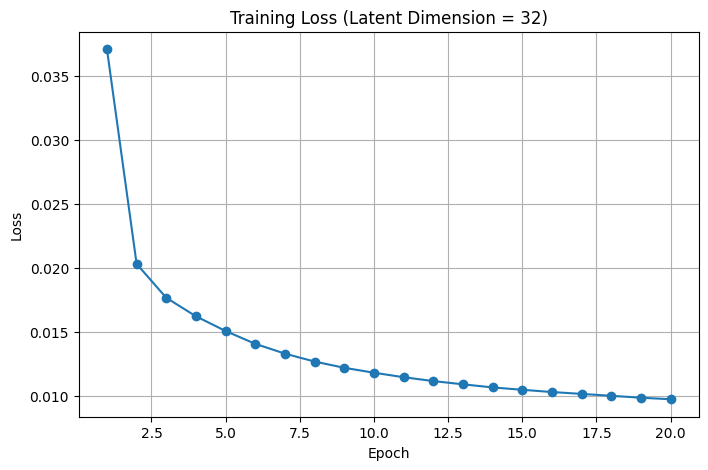

In [21]:
# Grafik Training Loss

plt.figure(figsize=(8,5))

plt.plot(range(1, epochs+1), loss_history, marker='o')

plt.title(f"Training Loss (Latent Dimension = {latent_dim})")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

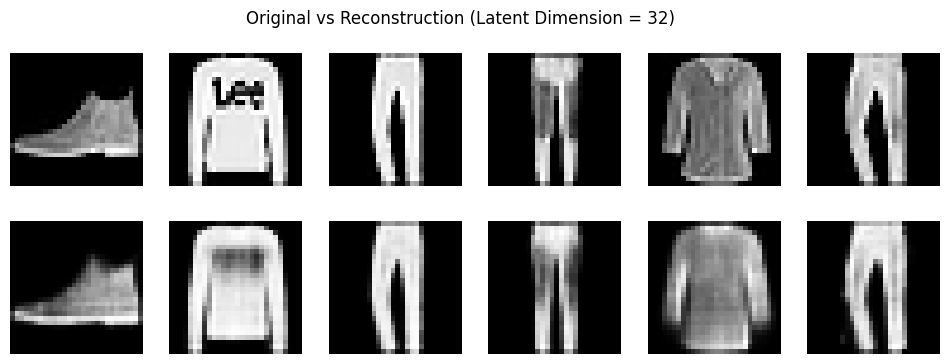

In [22]:
# Rekonstruksi Gambar

model.eval()

images, _ = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():
    reconstructed = model(images)

images = images.cpu()
reconstructed = reconstructed.cpu()

plt.figure(figsize=(12,4))

for i in range(6):

    # Gambar asli
    plt.subplot(2,6,i+1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.axis("off")

    # Hasil rekonstruksi
    plt.subplot(2,6,i+7)
    plt.imshow(reconstructed[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle(f"Original vs Reconstruction (Latent Dimension = {latent_dim})")

plt.show()

In [23]:
# Simpan Model
torch.save(model.state_dict(), f"autoencoder_latent_{latent_dim}.pth")

print(f"Model berhasil disimpan sebagai autoencoder_latent_{latent_dim}.pth")

Model berhasil disimpan sebagai autoencoder_latent_32.pth
